In [1]:
#!pip install duckdb
#%pip install duckdb-engine 

In [2]:
import duckdb
import pandas as pd

In [3]:
data_path = 'cleaned_data.csv'

In [4]:
#!pip install jupysql

In [5]:
%load_ext sql
%config SqlMagic.displaylimit = 20
%sql duckdb:///:memory:
%sql CREATE OR REPLACE TABLE events AS SELECT * FROM '{{data_path}}'


Connecting to 'duckdb:///:memory:'

Running query in 'duckdb:///:memory:'

Count


In [6]:
%sql SUMMARIZE events

Running query in 'duckdb:///:memory:'

column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
event_time,TIMESTAMP WITH TIME ZONE,2019-10-01 03:00:00+03,2020-03-01 01:59:59+02,8899573,2019-12-16 06:13:19.026896+02,None,2019-11-08 18:20:19.93342+02,2019-12-13 12:26:04.436908+02,2020-01-25 05:52:20.014155+02,19579532,0.00
event_type,VARCHAR,cart,view,4,None,None,None,None,None,19579532,0.00
product_id,BIGINT,3752,5932595,50843,5481791.269801495,1310928.0117079464,5725440,5811248,5858052,19579532,0.00
category_id,BIGINT,1487580004807082827,2242903426784559183,526,1.5545015703014738e+18,1.6945843102676186e+17,1487580005778889728,1487580008337446656,1487580013472057600,19579532,0.00
brand,VARCHAR,airnails,zinger,271,None,None,None,None,None,19579532,0.00
price,DOUBLE,0.0,327.78,2541,8.740309647341771,19.76414289842286,2.13141734312227,4.112651092299284,7.112595151401597,19579532,0.00
user_id,BIGINT,465496,622090237,1420479,522088996.2794268,87726649.191304,483491856,554008614,579754988,19579532,0.00
user_session,VARCHAR,0000061d-f3e9-484b-8c73-e54f355032a3,fffffc08-81e3-4050-9cd6-a5301f79f6f1,5527500,None,None,None,None,None,19579532,0.00
hour,BIGINT,0,23,24,13.08647172976351,5.471540854803132,9,13,18,19579532,0.00
weekday,BIGINT,0,6,7,2.916961038701027,1.9770321013111753,1,3,5,19579532,0.00


## Funnel analysis: view -> cart -> purchase (remove_from_cart ignored)

Shows funnel conversion from previous step.


In [7]:
%%sql funnel_data <<
select 
    *,
    round(clicks*100/IFNULL(LAG(clicks) OVER (ORDER BY funnel_sequence), clicks),2) as conversion_rate
from (
        select 
            (case
                when event_type = 'view' then 1
                when event_type = 'cart' then 2
                when event_type = 'purchase' then 3
            end) as funnel_sequence,
            event_type,
            count(event_type) as clicks
        from events
            where event_type <> 'remove_from_cart'
        group by funnel_sequence, event_type
        order by funnel_sequence
        )


Running query in 'duckdb:///:memory:'

In [8]:
df_funnel = funnel_data.DataFrame()
df_funnel

,funnel_sequence,event_type,clicks,conversion_rate
0,1,view,9656757,100.00
1,2,cart,5649646,58.50
2,3,purchase,1285982,22.76


In [9]:
df_funnel.to_csv('./data_to_visualize/export_funnel.csv', sep=';',index=False)

**Result: 58.5% events were converted from view to cart, 22.76% events were converted from cart to purchase.** 

In [10]:
#!pip install plotly
#!pip install --upgrade nbformat


In [11]:
from plotly import graph_objects as go

fig = go.Figure(
    go.Funnel(
        y = df_funnel.event_type,
        x = df_funnel.clicks,
        textinfo='value+percent initial',
        marker={
            'color':["purple","blue","green"]
        }
    )
)
fig.update_layout(title_text = 'Events Funnel Analysis', title_x = 0.5)
fig.show()

### Number of unique users
Total distinct users who interacted with store across all event types

In [12]:
%%sql 
select 
    count(distinct user_id) as total_users
from events

Running query in 'duckdb:///:memory:'

total_users
1639151


### Average session duration

Shows how much time people spend to end their session.

In [13]:
%%sql
select 
    round(AVG(duration)/60,2) as 'avg_duration, h'
from 
    (select
        user_session,
        date_diff('minute', min(event_time), max(event_time)) as duration
    from events
    group by user_session)


Running query in 'duckdb:///:memory:'

"avg_duration, h"
4.28


### Session conversion rate

Shows how many sessions ended up with purchase.

In [14]:
%%sql
select 
    count(DISTINCT case when event_type = 'purchase' then user_session end) as purchasing_sessions,
    count(DISTINCT user_session) as total_sessions,
    round(count(DISTINCT case when event_type = 'purchase' then user_session end)*100/
        count(DISTINCT user_session)
        ,2) as 'session_conversion_rate, %'

from events

Running query in 'duckdb:///:memory:'

purchasing_sessions,total_sessions,"session_conversion_rate, %"
155617,4535940,3.43


### Monthly conversion rate
Shows conversion from view to purchase over time.

In [15]:
%%sql
select 
    month,
    year,
    count(case when event_type = 'purchase' then 1 end) as purchases,
    count(case when event_type = 'view' then 1 end) as views,
    round(count(case when event_type = 'purchase' then 1 end)*100/
        count(case when event_type = 'view' then 1 end)
        ,2) as 'conversion_rate, %'
from events
group by year, month 
order by year, month

Running query in 'duckdb:///:memory:'

month,year,purchases,views,"conversion_rate, %"
10,2019,245261,1862047,13.17
11,2019,322253,2075984,15.52
12,2019,213049,1728216,12.33
1,2020,263570,2037491,12.94
2,2020,241849,1953019,12.38


### Total Revenue per month

Shows revenue received over time by month.

In [16]:
%%sql monthly_revenue << 
select 
    year,
    month,
    round(SUM(price),2) as revenue
from events
where event_type = 'purchase'
group by year, month
order by year, month

Running query in 'duckdb:///:memory:'

In [17]:
monthly_revenue_df = monthly_revenue.DataFrame()
monthly_revenue_df['year_month'] = pd.to_datetime(monthly_revenue_df[['year','month']].assign(day=1)).dt.strftime('%Y-%m')
monthly_revenue_df

,year,month,revenue,year_month
0,2019,10,1210921.55,2019-10
1,2019,11,1530831.06,2019-11
2,2019,12,1077689.23,2019-12
3,2020,1,1321825.06,2020-01
4,2020,2,1207000.80,2020-02


<Axes: title={'center': 'Monthly Revenue Over Time'}, xlabel='Month', ylabel='Revenue'>

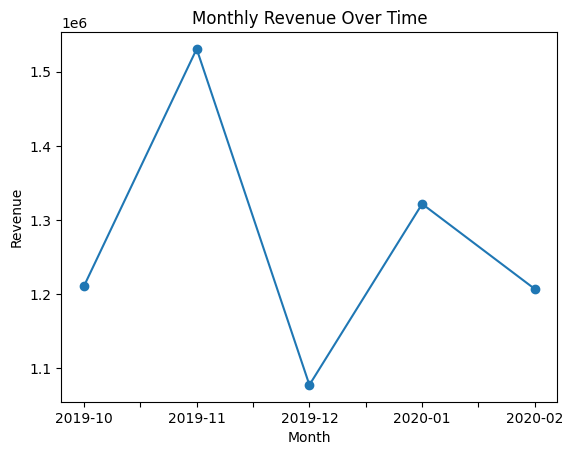

In [18]:
monthly_revenue_df.plot.line(
    x='year_month', 
    y = 'revenue', 
    marker='o',
    title = 'Monthly Revenue Over Time',
    xlabel = 'Month',
    ylabel = 'Revenue',
    legend = False
)

### Total Revenue per week 

Shows revenue received over time by weeks.

In [19]:
%%sql weekly_revenue << 
select 
    week_number,
    round(SUM(price),2) as revenue
from events
where event_type = 'purchase'
group by week_number
order by week_number

Running query in 'duckdb:///:memory:'

In [20]:
weekly_revenue_df = weekly_revenue.DataFrame()
weekly_revenue_df.to_csv('./data_to_visualize/weekly_revenue.csv', sep=';', index=False)

### Which brands generate the most revenue?
Shows top 10 brands with the most revenue (based on purchase).

In [21]:
%%sql
select 
    brand,
    round(SUM(price),2) as revenue
from events
where event_type = 'purchase' 
    and brand <> 'unknown' 
group by brand
order by revenue desc
limit 10

Running query in 'duckdb:///:memory:'

brand,revenue
runail,343306.15
grattol,266295.94
irisk,223771.21
uno,190719.46
strong,151941.8
masura,138568.45
jessnail,134775.04
ingarden,124570.0
estel,121714.03
cnd,106327.8


### Revenue by brand

In [22]:
%%sql revenue_by_brand <<
select 
    brand,
    round(SUM(price),2) as revenue
from events
where event_type = 'purchase' 
    and brand <> 'unknown' 
group by brand
order by revenue desc

Running query in 'duckdb:///:memory:'

In [23]:
revenue_by_brand_df = revenue_by_brand.DataFrame()
revenue_by_brand_df.to_csv('./data_to_visualize/revenue_by_brand.csv', sep=';', index=False)

### What is average order value?
How much money average user pays for order. 

In [24]:
%%sql
select 
    round(AVG(price),2) as avg_order_value
from events
where event_type = 'purchase' 


Running query in 'duckdb:///:memory:'

avg_order_value
4.94


### Top products by purchase
Shows top 10 the most purchasable product ids. 

In [25]:
%%sql
select 
  product_id,
  count(*) as total_purchases
from events
where event_type = 'purchase'
group by product_id
order by total_purchases desc
limit 10

Running query in 'duckdb:///:memory:'

product_id,total_purchases
5809910,7549
5854897,4630
5700037,3682
5802432,3533
5751422,3521
5809912,3307
5815662,3246
5304,3133
5751383,2948
5849033,2782


### Purchase activity by days of week
Shows distribution over week by activities.

In [26]:
%%sql weekly_purchases <<
select 
  weekday,
  CASE weekday
    WHEN 0 THEN 'Monday'
    WHEN 1 THEN 'Tuesday'
    WHEN 2 THEN 'Wednesday'
    WHEN 3 THEN 'Thursday'
    WHEN 4 THEN 'Friday'
    WHEN 5 THEN 'Saturday'
    WHEN 6 THEN 'Sunday'
  END as day_name,
  count(*) as activities
from events
where event_type = 'purchase'
group by weekday, day_name
order by weekday


Running query in 'duckdb:///:memory:'

In [27]:
weekly_purchases_df = weekly_purchases.DataFrame()
weekly_purchases_df

,weekday,day_name,activities
0,0,Monday,185042
1,1,Tuesday,192349
2,2,Wednesday,184304
3,3,Thursday,206004
4,4,Friday,198220
5,5,Saturday,155638
6,6,Sunday,164425


In [28]:
weekly_purchases_df.to_csv('./data_to_visualize/weekly_purchases.csv', sep=';', index=False)

<Axes: title={'center': 'Purchase Activity by Days of Week'}, xlabel='day_name'>

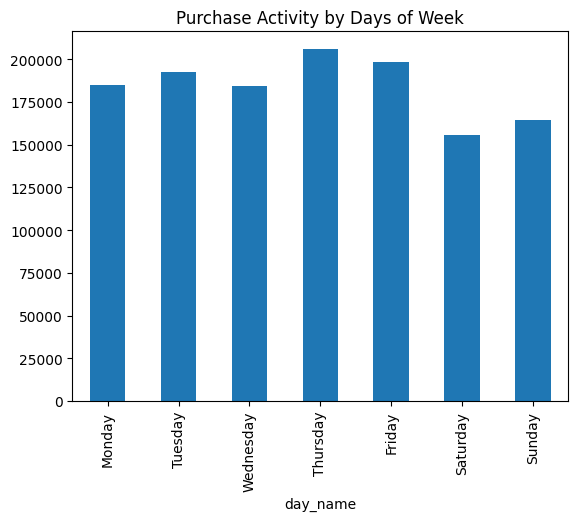

In [29]:
weekly_purchases_df.plot.bar(
    x = 'day_name',
    y = 'activities',
    legend = False,
    title = 'Purchase Activity by Days of Week'
)

**Result: Thursday had the highest purchase activity. Weekends are the least active days.**

### Purchase activity by weekends
Show distribution of purchases over week by weekend or not.

In [30]:
%%sql weekend <<
select 
  if(is_weekend, 'Weekend', 'Not Weekend') as day_type,
  count(*) as total_purchases,
  ROUND(count(*)/count(distinct day_number),2) as avg_daily_purchases
from events
where event_type = 'purchase'
group by day_type
order by day_type

Running query in 'duckdb:///:memory:'

In [31]:
weekend_df = weekend.DataFrame()
weekend_df.to_csv('./data_to_visualize/weekend.csv', sep=';', index=False)

In [32]:
weekend_df

,day_type,total_purchases,avg_daily_purchases
0,Not Weekend,965919,8861.64
1,Weekend,320063,7443.33


### Cart abandonment rate
What part of items added to cart were removed later?

In [33]:
%%sql
select 
  ROUND(
    SUM(CASE WHEN event_type = 'remove_from_cart' THEN 1 ELSE 0 END)*100/
    SUM(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END),
    2) as abandonment_rate
from events

Running query in 'duckdb:///:memory:'

abandonment_rate
52.87


**Result: 52.87% items removed before purchase.**

### Retention rate (by purchases)
How many users have repeated purchases.

In [34]:
%%sql
select
    count(*) as repeat_buyers,
    (select count(distinct user_id) from events) as total_users,
    round(
        count(*)*100/(select count(distinct user_id) from events)
        ,2) as '% of_total_users'
from (
    select 
        user_id,
        count(*) as total_purchases
    from events
    where event_type = 'purchase'
    group by user_id
    having total_purchases>=2
)

Running query in 'duckdb:///:memory:'

repeat_buyers,total_users,% of_total_users
99084,1639151,6.04


### Key metrics summary

In [35]:
%%sql metrics <<
SELECT
    COUNT(DISTINCT user_id) as total_users,
    ROUND(AVG(CASE WHEN event_type = 'purchase' THEN price END), 2) as avg_order_value,
    ROUND(COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_session END) * 100 /
        COUNT(DISTINCT user_session),2) as session_conversion_rate,
    ROUND(SUM(CASE WHEN event_type = 'remove_from_cart' THEN 1 ELSE 0 END)*100/
        SUM(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END),2) as cart_abandonment_rate
FROM events



Running query in 'duckdb:///:memory:'

In [36]:
metrics.DataFrame().to_csv('./data_to_visualize/export_metrics.csv', sep=';', index=False)
